In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import helpers
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"


train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)

sensors.head()

,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0


In [7]:
import os
os.getcwd()

'c:\\Users\\alice\\OneDrive - epfl.ch\\Documents\\GitHub\\FinalProject_ML'

In [8]:
print(train.info())
print(sensors.shape)
print(test.shape)

<class 'pandas.DataFrame'>
RangeIndex: 6626928 entries, 0 to 6626927
Data columns (total 4 columns):
 #   Column       Dtype   
---  ------       -----   
 0   sensor       category
 1   time         float64 
 2   power        float32 
 3   temperature  float32 
dtypes: category(1), float32(2), float64(1)
memory usage: 113.8 MB
None
(325, 4)
(2190480, 3)


<Axes: xlabel='coor_x', ylabel='coor_y'>

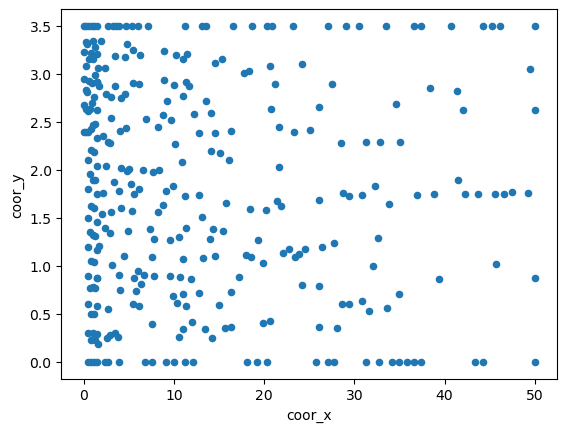

In [9]:
sensors.plot(kind='scatter', x='coor_x', y='coor_y')

In [10]:
X_train, y_train, X_test, y_test, feature_names = helpers.preprocess_data(train, label="temperature", train_size=0.8, seed=42)

In [11]:
def add_constant(X: np.ndarray) -> np.ndarray:
    """ Adds an constant term to the dataset (as the first column)

    Args:
        X (np.ndarray): Dataset of shape (N, D-1)

    Returns: 
        Dataset with offset term added, of shape (N, D)

    """
    X_with_offset = np.insert(X, 0, 1, axis=1)

    return X_with_offset

X_train = add_constant(X_train)
X_test = add_constant(X_test)

In [12]:
print('Training set features:')
print(f'X_train: \n {X_train[:10]}')

print('\nTraining set labels:')
print(f'y_train: \n {y_train[:10]}')

Training set features:
X_train: 
 [[1 'N729' 545184000.0 500.0]
 [1 'N196' 4490640000.0 0.0]
 [1 'N918' 6956755200.0 319.9784851074219]
 [1 'N4' 849398400.0 1001.7897338867188]
 [1 'N641' 4931366400.0 0.0]
 [1 'N66' 2339020800.0 1500.0]
 [1 'N862' 4620240000.0 0.0]
 [1 'N288' 373248000.0 500.0]
 [1 'N89' 820886400.0 500.0]
 [1 'N277' 404352000.0 1400.0]]

Training set labels:
y_train: 
 [  19.755325    21.049791   -14.5829735   45.018536    12.457679
   23.950861    -2.2813048   22.34978     17.282118  -292.15085  ]


In [13]:
# Show shapes
print('Training set shape:')
print(f'X: {X_train.shape}, y: {y_train.shape}')

print('\nTest set shape:')
print(f'X: {X_test.shape}, y: {y_test.shape}')

Training set shape:
X: (5301542, 4), y: (5301542,)

Test set shape:
X: (1325386, 4), y: (1325386,)


In [14]:
def mse_loss(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    """Computes the Mean Square Error (MSE)
                                   
    Args:
        X (np.ndarray): Dataset of shape (N, D)
        y (np.ndarray): Labels of shape (N, )
        w (np.ndarray): Weights of shape (D, )

    Returns:
        float: the MSE loss
    """
    ### START CODE HERE ### (≈ 3 lines of code)
    N = y.shape[0]
    y_hat = X @ w
    loss = (1/ N) * ((y_hat - y).T @ (y_hat - y))
    ### END CODE HERE ###
    return loss

In [15]:
zero_weights = np.zeros(X_train.shape[1])

In [16]:
train_loss = mse_loss(X_train, y_train, zero_weights)
test_loss = mse_loss(X_test, y_test, zero_weights)
print(f"Train loss: {train_loss:.5f}")
print(f"Test loss: {test_loss:.5f}")

TypeError: can't multiply sequence by non-int of type 'float'